In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [2]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [3]:
import itertools
import numpy as np

# Define the number of points in each linspace
num_points = 5  # Adjust as needed

# Define the intervals for each parameter
alpha_interval = np.linspace(0.1, 1.0, num_points)  # Range for alpha (external stimulation)
beta_interval = np.linspace(0.5, 1.5, num_points)   # Range for beta (recovery rate)
gamma_interval = np.linspace(-0.5, 0.5, num_points) # Range for gamma (shift in balance)

# Generate all combinations using itertools.product
combinations = list(itertools.product(alpha_interval, beta_interval, gamma_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

[[ 0.55   1.    -0.25 ]
 [ 0.325  1.5   -0.5  ]
 [ 0.325  1.     0.5  ]
 [ 0.55   1.     0.25 ]
 [ 1.     1.     0.5  ]
 [ 0.775  1.5    0.25 ]
 [ 0.55   0.5    0.   ]
 [ 1.     0.5    0.   ]
 [ 0.775  0.75   0.5  ]
 [ 0.325  1.     0.25 ]
 [ 0.1    0.5    0.   ]
 [ 0.55   1.25   0.25 ]
 [ 1.     0.5    0.25 ]
 [ 0.775  1.5    0.   ]
 [ 0.325  1.     0.   ]
 [ 0.1    0.5   -0.25 ]
 [ 0.775  0.75   0.25 ]
 [ 0.55   0.75  -0.5  ]
 [ 0.1    1.    -0.5  ]
 [ 0.325  1.25   0.25 ]
 [ 0.775  0.75   0.   ]
 [ 0.325  1.5    0.25 ]
 [ 0.325  1.5    0.   ]
 [ 0.775  1.25   0.5  ]
 [ 0.325  0.5   -0.25 ]
 [ 0.325  1.25  -0.25 ]
 [ 0.1    1.25   0.5  ]
 [ 0.1    1.     0.5  ]
 [ 0.775  1.    -0.5  ]
 [ 0.325  1.    -0.5  ]
 [ 0.1    1.5   -0.5  ]
 [ 1.     0.75   0.   ]
 [ 1.     1.25  -0.5  ]
 [ 0.1    0.5    0.25 ]
 [ 0.775  1.5    0.5  ]
 [ 1.     1.    -0.5  ]
 [ 1.     1.    -0.25 ]
 [ 0.775  0.5   -0.5  ]
 [ 0.775  1.25   0.   ]
 [ 0.775  1.25  -0.5  ]
 [ 0.55   0.75  -0.25 ]
 [ 0.55   0.75  

In [4]:
import itertools
import numpy as np

# Define the number of points in each linspace
# Define the number of points in the linspace
num_points = 5  # Adjust as needed

# Define the intervals for each parameter
mu_interval = np.linspace(0.1, 2.0, num_points)     # Range for mu (damping and nonlinearity)
omega_interval = np.linspace(0.5, 2.5, num_points)  # Range for omega (forcing frequency)

# Generate all combinations using itertools.product
combinations = list(itertools.product(mu_interval, omega_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

[[2.    1.   ]
 [0.575 2.5  ]
 [0.1   2.5  ]
 [1.525 0.5  ]
 [0.575 1.5  ]
 [1.05  1.5  ]
 [0.575 2.   ]
 [1.05  0.5  ]
 [1.05  2.5  ]
 [2.    2.5  ]
 [1.525 2.5  ]
 [0.1   1.   ]
 [1.525 1.   ]
 [1.525 1.5  ]
 [0.575 0.5  ]
 [2.    2.   ]
 [1.05  1.   ]
 [1.05  2.   ]
 [1.525 2.   ]
 [2.    0.5  ]
 [0.1   2.   ]
 [0.1   1.5  ]
 [0.1   0.5  ]
 [2.    1.5  ]
 [0.575 1.   ]]


In [5]:
solver_HF = System4()
solver_LF = System4()

num_params=3
params=combinations_array[0:10,:]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=10.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_3params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=10.0, params=params, h=0.04, fidelity='LF')   #0.04
solver_LF.save_dataset('dataset_LF_3params.h5')


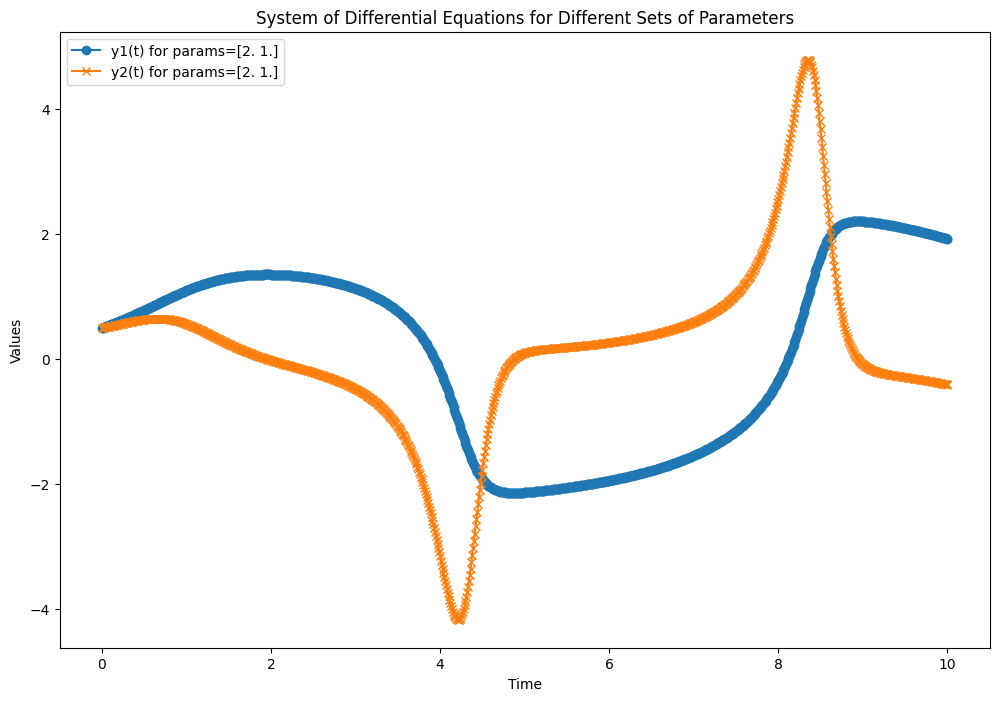

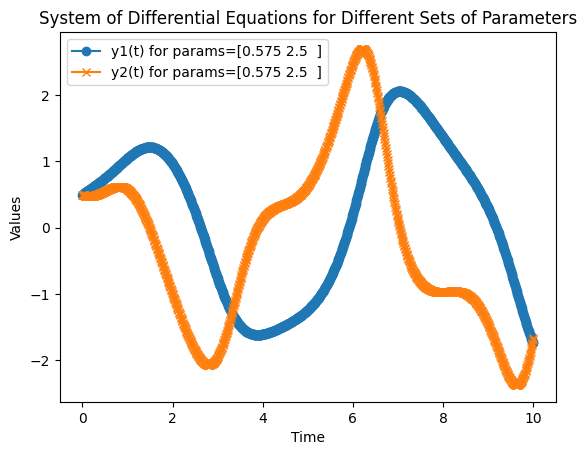

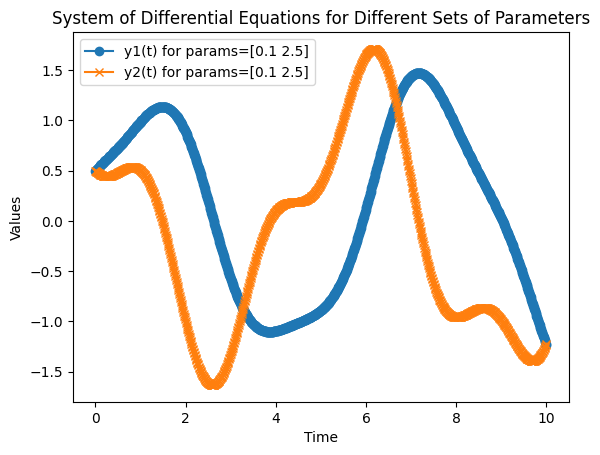

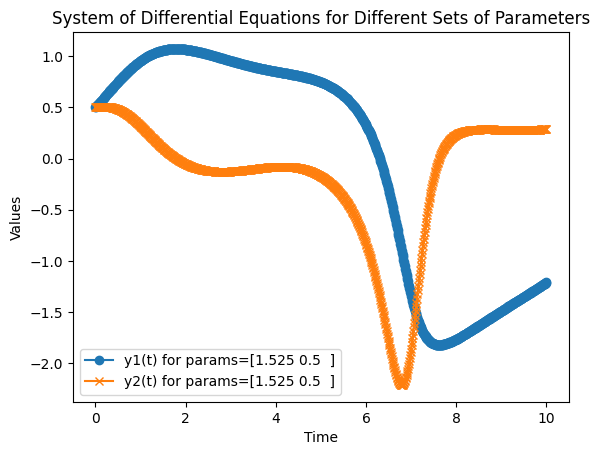

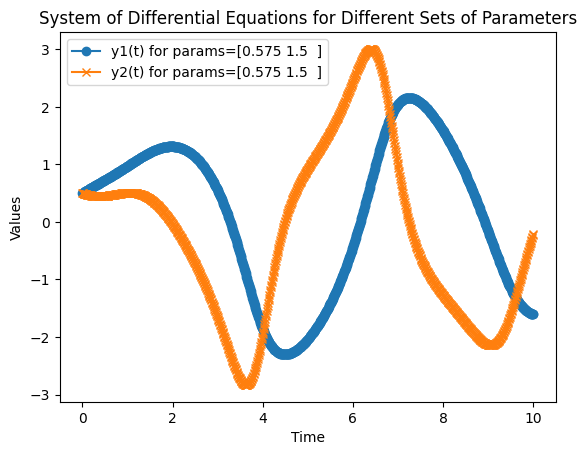

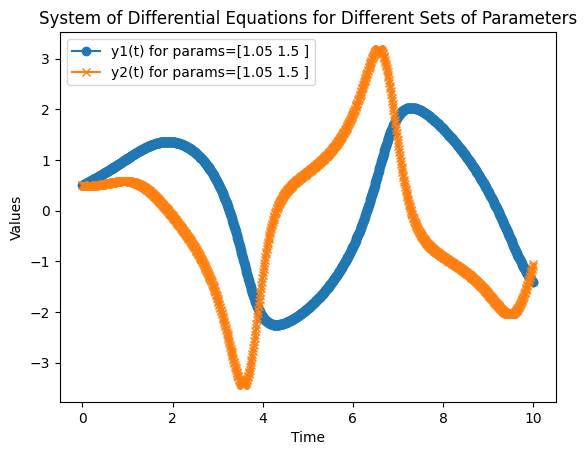

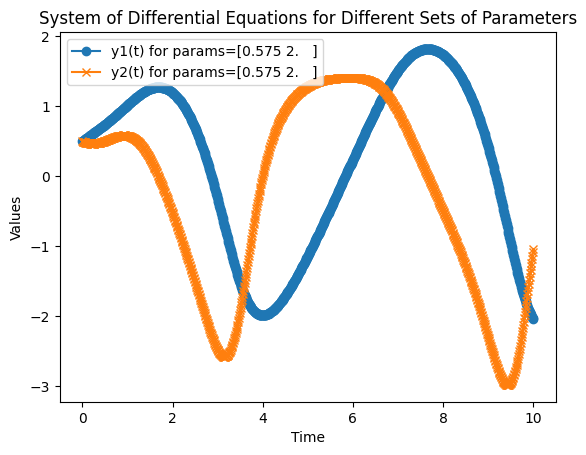

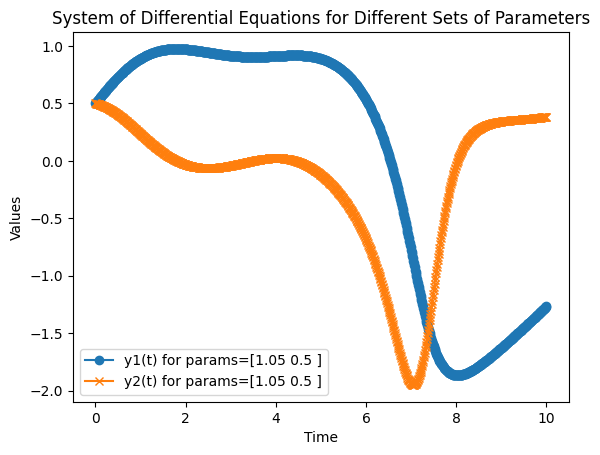

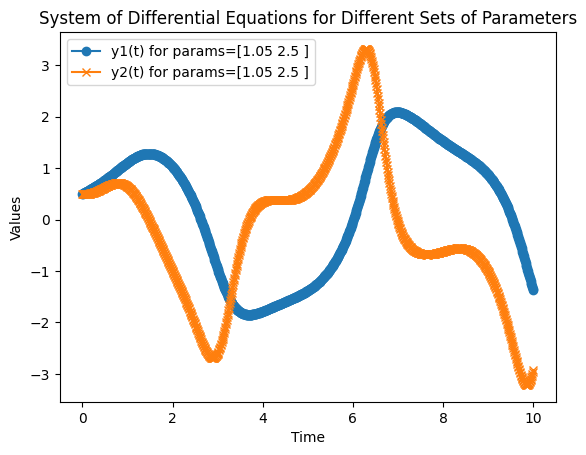

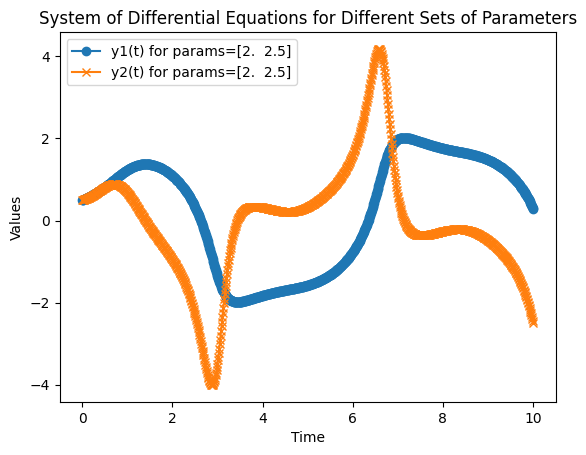

In [6]:
solver_HF.plot_results()

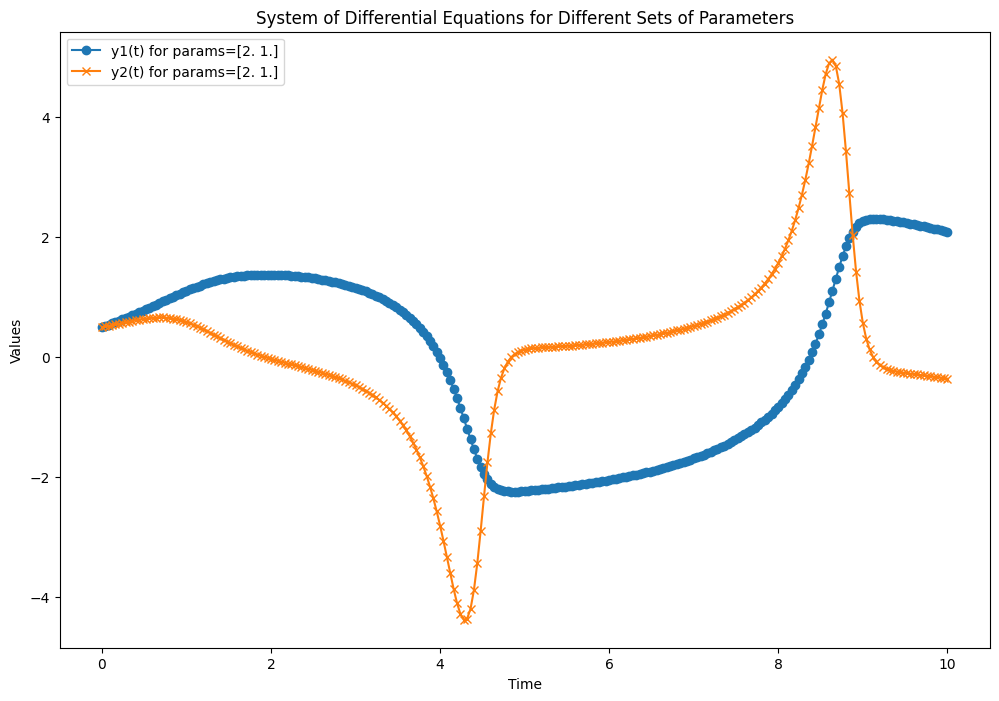

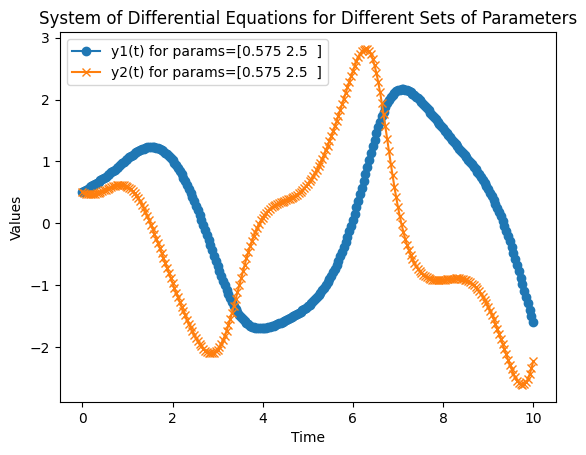

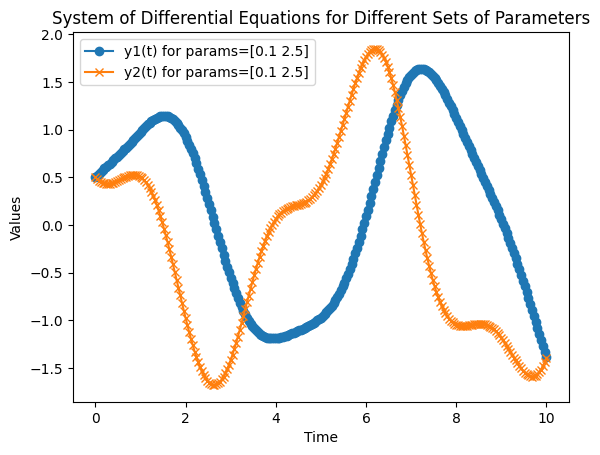

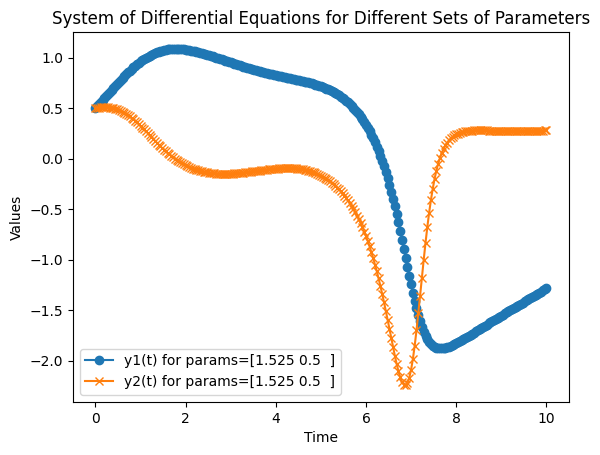

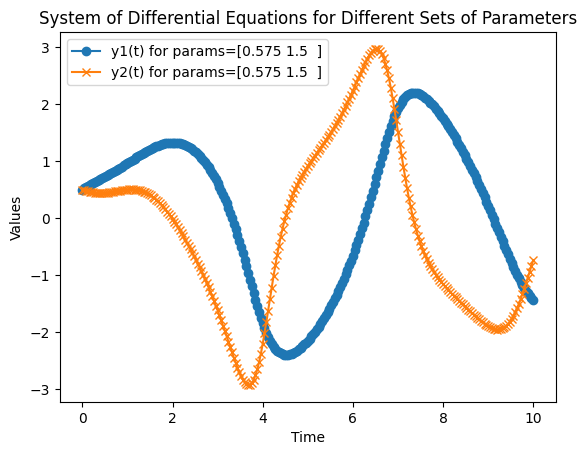

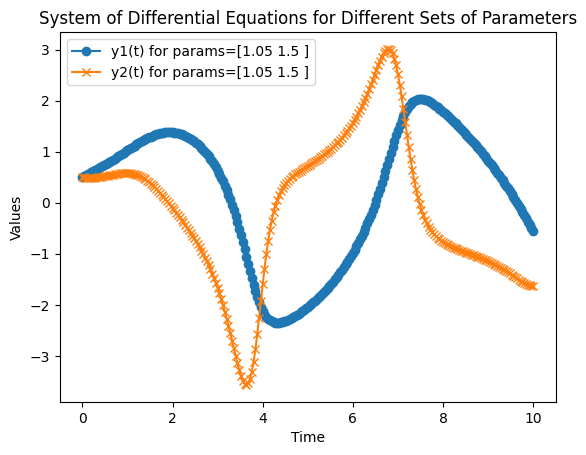

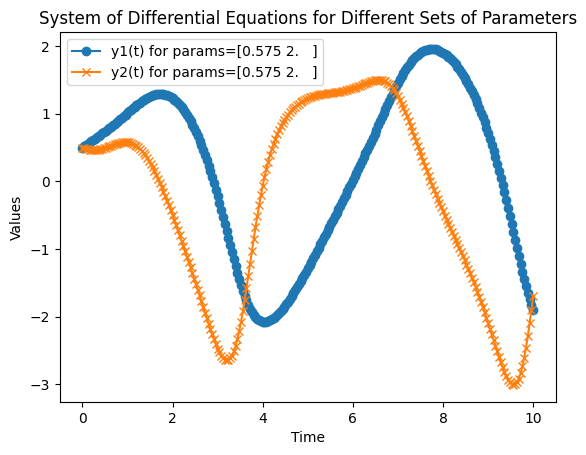

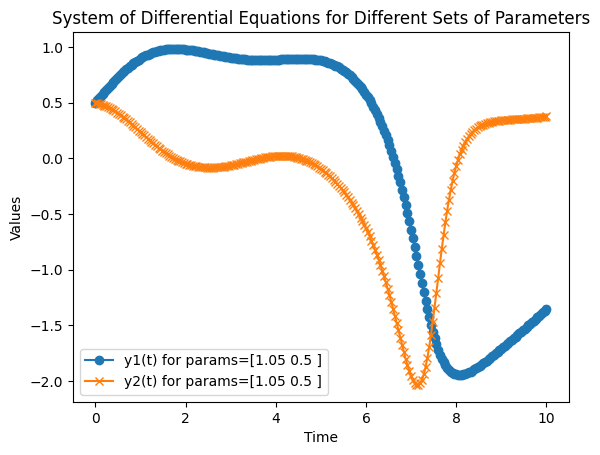

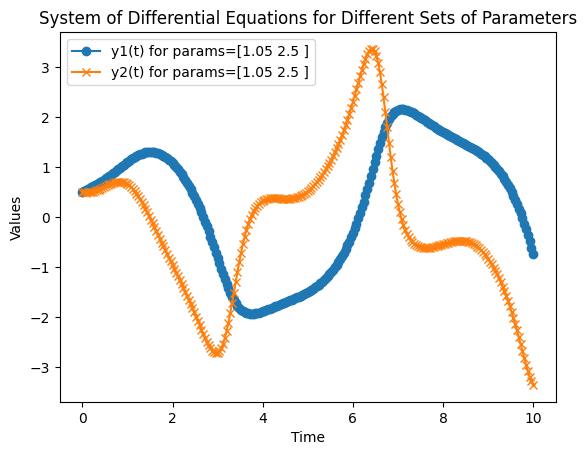

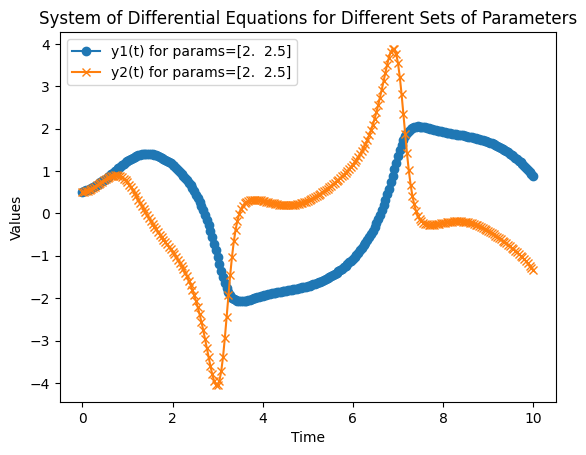

In [7]:
solver_LF.plot_results()

In [8]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [9]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())

In [10]:
y_HF.shape

(10010, 2)

In [10]:
N=10000
n=1000
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
definition_HF = {
    "network_type": "LF",
    "params": bestLF_params,
    "data_train": x_HF,
    "output_train": y_HF,
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}
HF_model = NetworkFactory.build_network(**definition_HF)


solver_test=System4()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=10.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=HF_model.prediction(datatest)

(mse_MF,R_MF)=HF_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

KeyboardInterrupt: 

The function training took 0.928244 seconds.


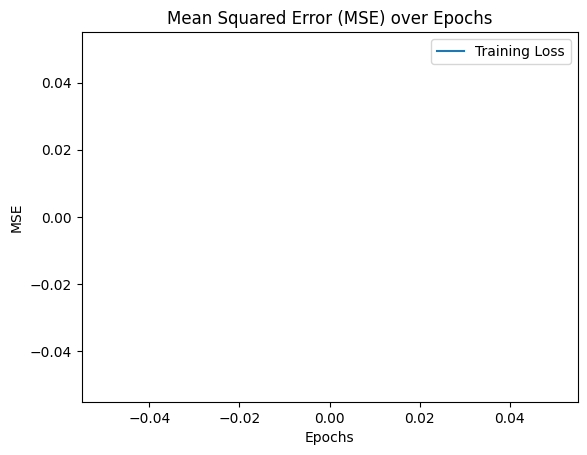

The function training took 1.127805 seconds.


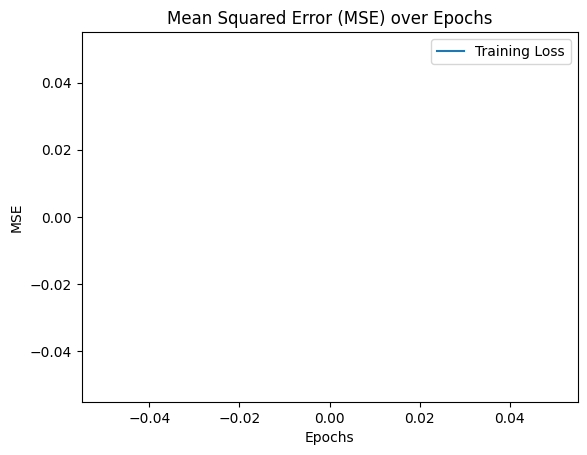

Test MSE: 1.4544636647300808
R^2: 0.15018237082881813


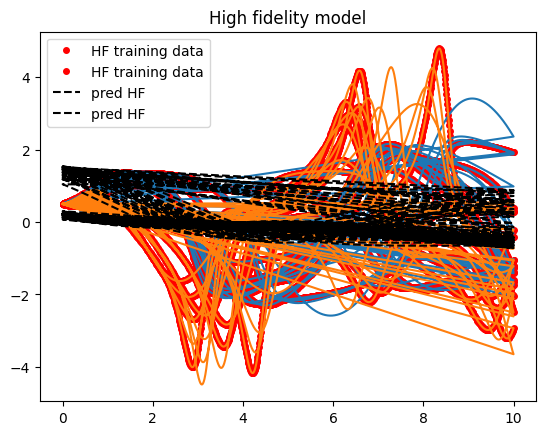

In [14]:
N=[10,10]#N=[1000,10000]
n=[500,1000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System4()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=10.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

The function training took 28.737474 seconds.


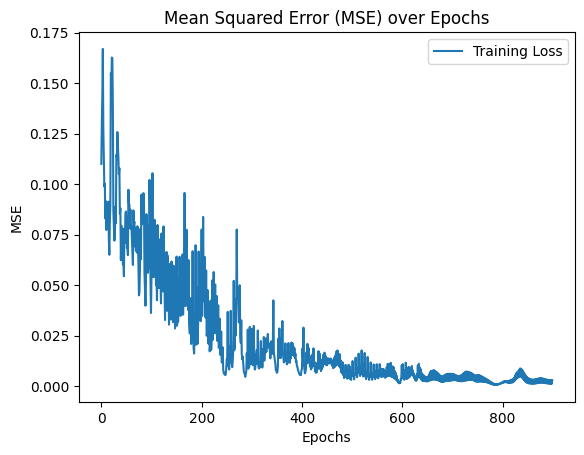

The function training took 43.318846 seconds.


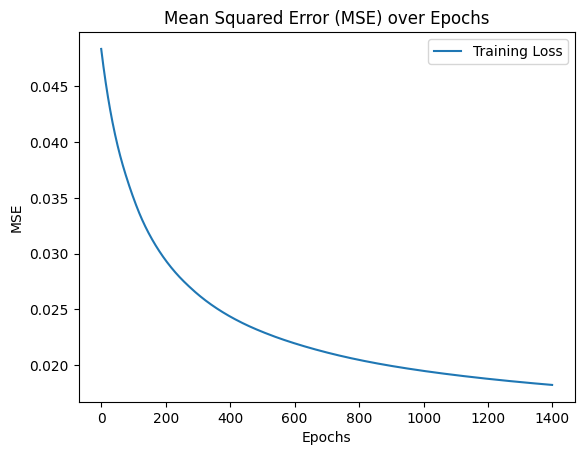

The function training took 264.457855 seconds.


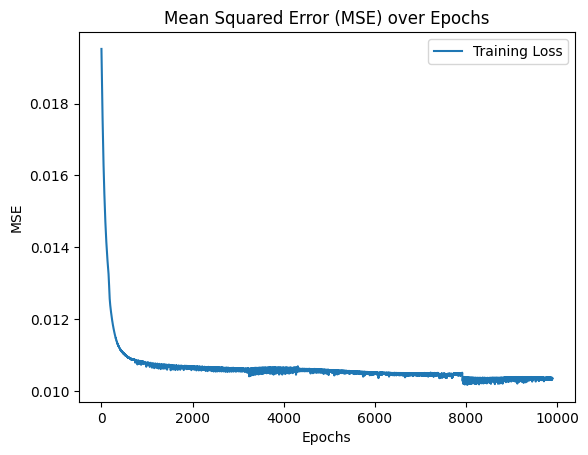

Test MSE: 0.3040749878362892
R^2: 0.8223343136583294


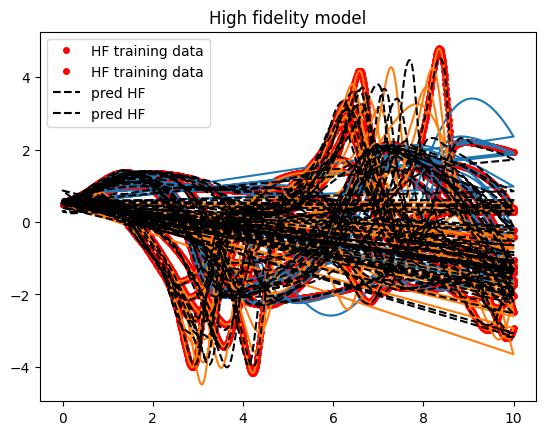

In [13]:
N=[1000,1500,10000]#N=[1000,10000]
n=[500,750,1000]
names=["LF","Hfper","HF"]

bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
bestper_params = {
    "lr": 0.002,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
    "l2weight": 0.01,
}
best_params={'kernel_init': 'uniform', 
            'l2weight': 0.005395541657336886, 
            'lr': 0.0025412188591473228, 
            'nodes': 12.0, 
            'opt': 'Adamax'}

names=["LF","Hfper","HF"]

params_NN=[bestLF_params, bestper_params,best_params]

# collection of the parameters
definition_3steps = {
    "network_type": "3step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF,x_HF],
    "output_train": [y_LF, y_HF,y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_3steps)

solver_test=System4()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=10.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

TypeError: list indices must be integers or slices, not tuple

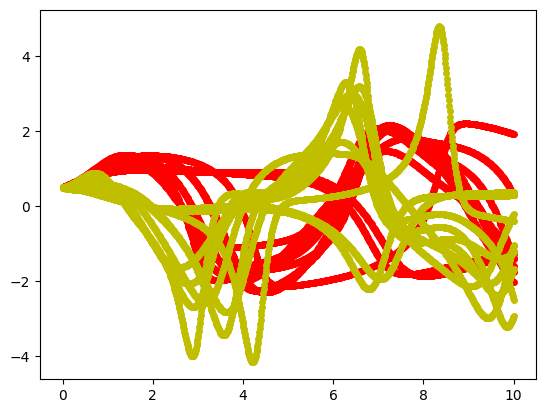

In [20]:

# Plotting data
plt.plot(x_HF[:, 0], y_HF[:,0], 'ro', label='HF training data', markersize=4)
plt.plot(x_HF[:, 0], y_HF[:,1], 'yo', label='HF training data', markersize=4)

plt.plot(datatest[:, 0], np.array(y_test[:,0]).reshape(-1, 2))
plt.plot(datatest[:, 0], np.array(y_test[:,1]).reshape(-1, 2))

# plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title

HPO name  LF


[I 2024-08-15 22:00:29,241] A new study created in RDB with name: no-name-63858633-17a4-4cdc-a6cd-4b42bd586f50
[I 2024-08-15 22:00:39,954] Trial 2 finished with value: 1.4803679473224385 and parameters: {'nodes': 14, 'l2weight': 0.08386799358494097, 'lr': 0.003955974093088768, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 1.4803679473224385.
[I 2024-08-15 22:00:39,996] Trial 3 finished with value: 1.5876317273284908 and parameters: {'nodes': 7, 'l2weight': 0.007524606645302675, 'lr': 0.0008415878971088851, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 1.4803679473224385.
[I 2024-08-15 22:00:40,026] Trial 0 finished with value: 1.621021223714376 and parameters: {'nodes': 10, 'l2weight': 0.0009791916185388863, 'lr': 0.0014891894239602414, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 2 with value: 1.4803679473224385.
[I 2024-08-15 22:00:40,101] Trial 1 finished with value: 1.5870698012964413 and parameters: {'n

The function training took 1.653733 seconds.


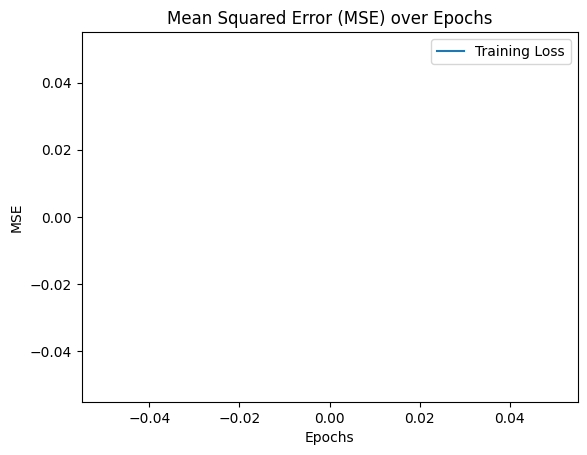

[I 2024-08-15 22:00:42,385] A new study created in RDB with name: no-name-d1ee8811-699e-48e9-a489-1a62baa1c9b3


HPO name  HF


[I 2024-08-15 22:00:45,778] Trial 0 finished with value: 1.3500649272069896 and parameters: {'nodes': 7, 'l2weight': 0.0010567005997490389, 'lr': 0.023887172183309182, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 1.3500649272069896.
[I 2024-08-15 22:00:45,803] Trial 1 finished with value: 1.5577652303514724 and parameters: {'nodes': 8, 'l2weight': 0.009552992974737377, 'lr': 0.0004011095029124468, 'kernel_init': 'uniform', 'opt': 'Adam'}. Best is trial 0 with value: 1.3500649272069896.
[I 2024-08-15 22:00:55,688] Trial 3 finished with value: 1.3070181185120928 and parameters: {'nodes': 37, 'l2weight': 0.000658564401073801, 'lr': 0.009524629975073228, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 3 with value: 1.3070181185120928.
[I 2024-08-15 22:00:55,758] Trial 2 finished with value: 1.7985913346403288 and parameters: {'nodes': 32, 'l2weight': 0.0005280282953658819, 'lr': 0.00011292588472681998, 'kernel_init': 'glorot_uniform', 'opt

The function training took 1.867897 seconds.


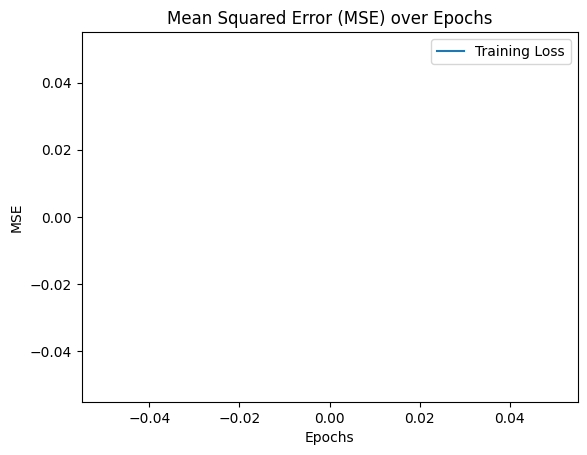

Test MSE: 0.9433582577218954
R^2: 0.4488123027913151


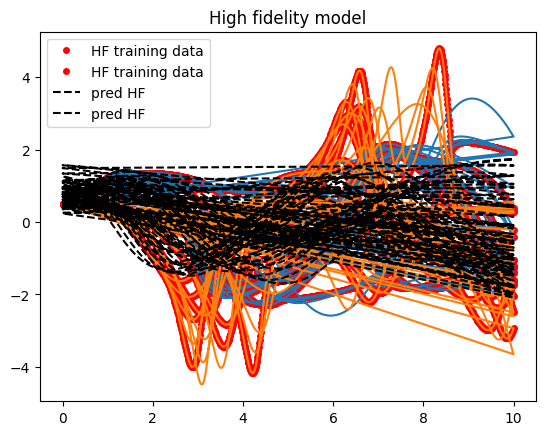

In [11]:
N=[50,50]#N=[1000,10000]
n=[500,1000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_3steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System4()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=10.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 2))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

In [ ]:
final_model.model_list[1].input_shape

3

In [2]:
datatest

NameError: name 'datatest' is not defined

In [3]:
mu_test

NameError: name 'mu_test' is not defined

TypeError: list indices must be integers or slices, not tuple

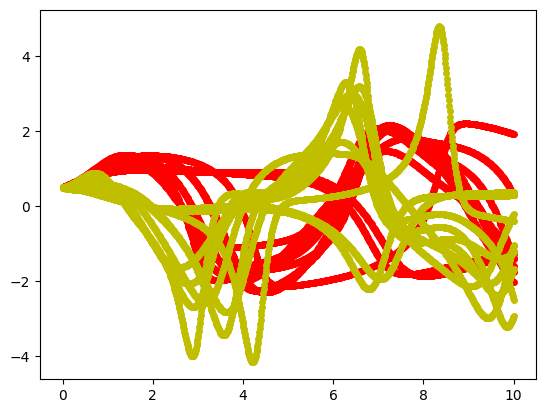

In [21]:

# Plotting data
plt.plot(x_HF[:, 0], y_HF[:,0], 'ro', label='HF training data', markersize=4)
plt.plot(x_HF[:, 0], y_HF[:,1], 'yo', label='HF training data', markersize=4)

plt.plot(datatest[:, 0], np.array(y_test[:,0]).reshape(-1, 2))
plt.plot(datatest[:, 0], np.array(y_test[:,1]).reshape(-1, 2))

# plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title

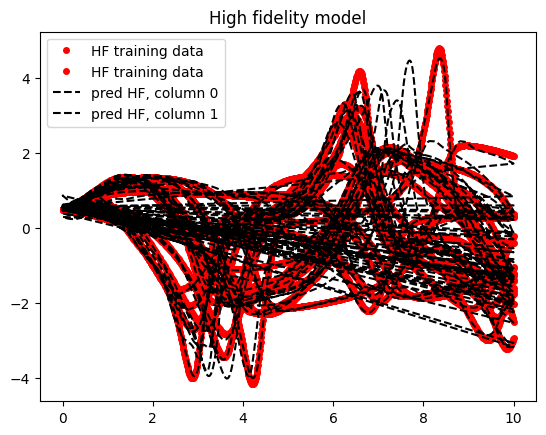

In [23]:
# Plotting HF training data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)

# Iterating over each row in datatest to plot the corresponding prediction
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], 'k--', label=f'pred HF, column {i}')

# Adding title and legend
plt.title("High fidelity model")
plt.legend()
plt.show()

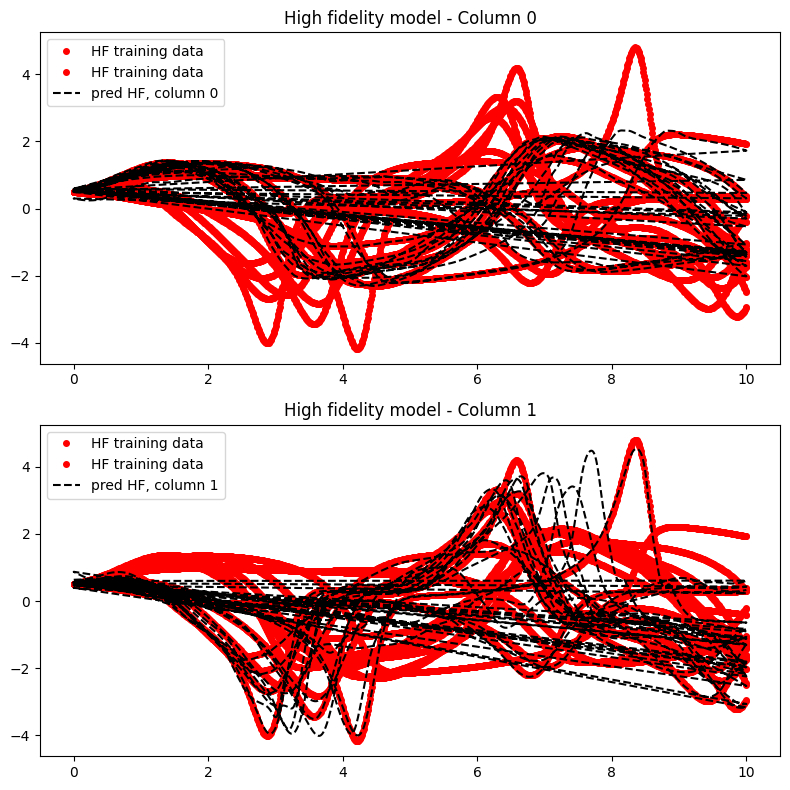

In [25]:
import matplotlib.pyplot as plt

# Number of columns in y_test_pred
n_cols = y_test_pred.shape[1]

# Create subplots
fig, axs = plt.subplots(n_cols, 1, figsize=(8, 4*n_cols))

# Plot each prediction in its own subplot
for i in range(n_cols):
    axs[i].plot(x_HF[:, 0], y_HF, 'ro', markersize=4, label='HF training data')
    axs[i].plot(datatest[:, 0], y_test_pred[:, i], 'k--', label=f'pred HF, column {i}')
    axs[i].set_title(f"High fidelity model - Column {i}")
    axs[i].legend()

plt.tight_layout()
plt.show()


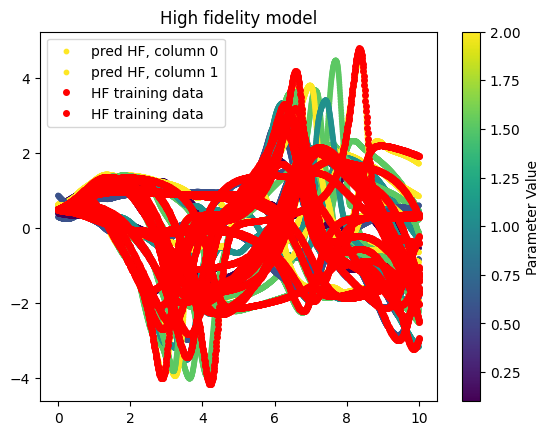

In [27]:
import matplotlib.pyplot as plt

# Assuming datatest[:, 1] is the parameter that varies
for i in range(y_test_pred.shape[1]):
    plt.scatter(datatest[:, 0], y_test_pred[:, i], c=datatest[:, 1], cmap='viridis', label=f'pred HF, column {i}', s=10)

# Plotting HF training data
plt.plot(x_HF[:, 0], y_HF, 'ro', markersize=4, label='HF training data')

# Adding title and legend
plt.title("High fidelity model")
plt.colorbar(label="Parameter Value")
plt.legend()
plt.show()

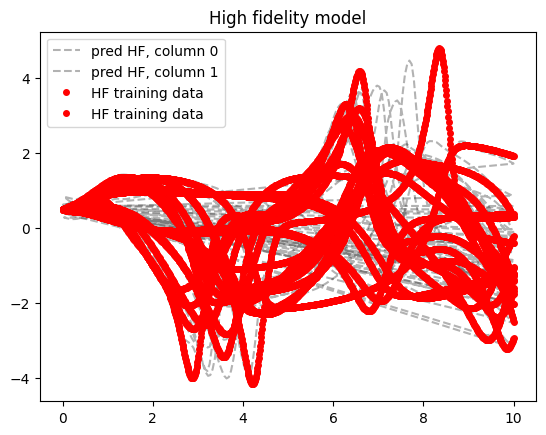

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Subsample data: plot only every nth point
n = 10  # Change n to adjust how many points you skip
subsample_indices = np.arange(0, datatest.shape[0], n)

# Plotting a subsample with transparency
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[subsample_indices, 0], y_test_pred[subsample_indices, i], 
             'k--', label=f'pred HF, column {i}', alpha=0.3)

# Plotting HF training data
plt.plot(x_HF[:, 0], y_HF, 'ro', markersize=4, label='HF training data')

# Adding title and legend
plt.title("High fidelity model")
plt.legend()
plt.show()
